# Figure 3 (FA) | Bone Marrow Hematopoiesis — FactorAnalysis + Palantir + Branch-Separated scJDO

Initial analysis & preprocessing from `examples/Palantir_sample_notebook_FA.ipynb`; — uses the bone marrow dataset (4,142 cells)  
with three lineages: **Erythroid (Ery)**, **Dendritic Cell (DC)**, **Monocyte (Mono)**.

| Step | Tool | What it does |
|---|---|---|
| 1 | FactorAnalysis + UMAP | `sklearn.decomposition.FactorAnalysis` embedding (1,000 HVGs, 30 factors) |
| 2 | Palantir | Branch-aware pseudotime + fate probabilities (diffusion maps built on the FA embedding) |
| 3 | scJDO | Branch-separated drift fields per lineage |
| 4 | scJDO | Instability genes + regulator networks |
| 5 | Figure | 6-panel manuscript figure |

In [1]:
#!pip install palantir

In [2]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('../..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import scanpy as sc
import palantir
import scjdo as sjd
from sklearn.decomposition import FactorAnalysis

mpl.rcParams.update({
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'font.family':  'DejaVu Sans',
    'axes.titlesize': 10, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'legend.fontsize': 8,
})

# ── Dataset (from Palantir sample notebook) ────────────────────────────────
DATA_PATH = '../examples/marrow_sample_scseq_counts.h5ad'

# Exact start/terminal cells from Palantir sample notebook
START_CELL      = 'Run5_164698952452459'
TERMINAL_STATES = pd.Series(
    ['DC',                   'Mono',                  'Ery'],
    index=['Run5_131097901611291', 'Run5_134936662236454', 'Run4_200562869397916']
)

# ── Pipeline config ────────────────────────────────────────────────────────
# Initial-analysis parameters — match examples/Palantir_sample_notebook_FA.ipynb
N_HVG           = 1000   # highly variable genes (cell_ranger)
N_LATENT        = 30     # FactorAnalysis components
FA_MAX_ITER     = 5000   # FactorAnalysis max_iter
N_DM_COMPONENTS = 20     # Palantir diffusion-map components
N_WAYPOINTS     = 500    # Palantir waypoints
# scJDO drift parameters
N_ARCHETYPES    = 5
N_EPOCHS        = 5000
BIAS_STRENGTH   = 1.5
SEED            = 42

# ── Output ─────────────────────────────────────────────────────────────────
OUTDIR = '../results/figure3/'
os.makedirs(OUTDIR, exist_ok=True)

BRANCH_COLORS = {'Ery': '#E63946', 'DC': '#2A9D8F', 'Mono': '#457B9D'}
ARCH_COLORS   = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D', '#8338EC']
K = N_ARCHETYPES

print(f'scjdo  v{sjd.__version__}')
print(f'palantir v{palantir.__version__}')
print(f'Latent: FactorAnalysis ({N_LATENT}-D)  |  Pseudotime: Palantir  |  Lineages: Ery / DC / Mono')

scjdo  v0.3.0
palantir v1.4.4
Latent: FactorAnalysis (30-D)  |  Pseudotime: Palantir  |  Lineages: Ery / DC / Mono


## Step 1 — Preprocessing & FactorAnalysis latent space
Exact recipe and parameters from `Palantir_sample_notebook_FA.ipynb`: normalize → `palantir.log_transform` → HVG (cell_ranger) → FactorAnalysis → diffusion maps → multiscale space → UMAP → MAGIC.

In [3]:
# ── Step 1: Load + preprocess (exact steps from Palantir sample notebook) ──
ad = sc.read(DATA_PATH)
print(f'Loaded: {ad.n_obs} cells × {ad.n_vars} genes')

ad.layers['raw_counts'] = ad.X.copy()
sc.pp.normalize_per_cell(ad)
palantir.preprocess.log_transform(ad)

# HVG selection + FactorAnalysis latent space (replaces PCA entirely)
sc.pp.highly_variable_genes(ad, n_top_genes=N_HVG, flavor='cell_ranger')

import scipy.sparse as _sp
_hvg  = ad.var['highly_variable'].values
_Xhvg = ad[:, _hvg].X
_Xhvg = _Xhvg.toarray() if _sp.issparse(_Xhvg) else np.asarray(_Xhvg, dtype=np.float32)

fa = FactorAnalysis(n_components=N_LATENT, random_state=SEED, max_iter=FA_MAX_ITER)
ad.obsm['X_fa'] = fa.fit_transform(_Xhvg).astype('float32')
# scJDO always reads gene loadings from varm['PCs'] regardless of the latent
# method; here it holds the FactorAnalysis loadings (genes x factors), zero-
# padded for non-HVG genes so instability genes map back to gene space.
_loadings = np.zeros((ad.n_vars, N_LATENT), dtype=np.float32)
_loadings[_hvg] = fa.components_.T.astype('float32')
ad.varm['PCs'] = _loadings
del _Xhvg, _loadings
print(f'FactorAnalysis: X_fa shape = {ad.obsm["X_fa"].shape}, '
      f'varm["PCs"] (FA loadings) shape = {ad.varm["PCs"].shape}')

# Diffusion maps + UMAP — built on the FactorAnalysis embedding (pca_key='X_fa')
dm_res  = palantir.utils.run_diffusion_maps(ad, n_components=N_DM_COMPONENTS, pca_key='X_fa')
ms_data = palantir.utils.determine_multiscale_space(ad)

sc.pp.neighbors(ad, use_rep='X_fa')
sc.tl.umap(ad)

# MAGIC imputation (required for gene trend visualization)
palantir.utils.run_magic_imputation(ad)

print(f'\nPreprocessing complete.')
print(f'obsm keys: {list(ad.obsm.keys())}')

Loaded: 4142 cells × 16106 genes


FactorAnalysis: X_fa shape = (4142, 30), varm["PCs"] (FA loadings) shape = (16106, 30)



Preprocessing complete.
obsm keys: ['X_fa', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_umap']


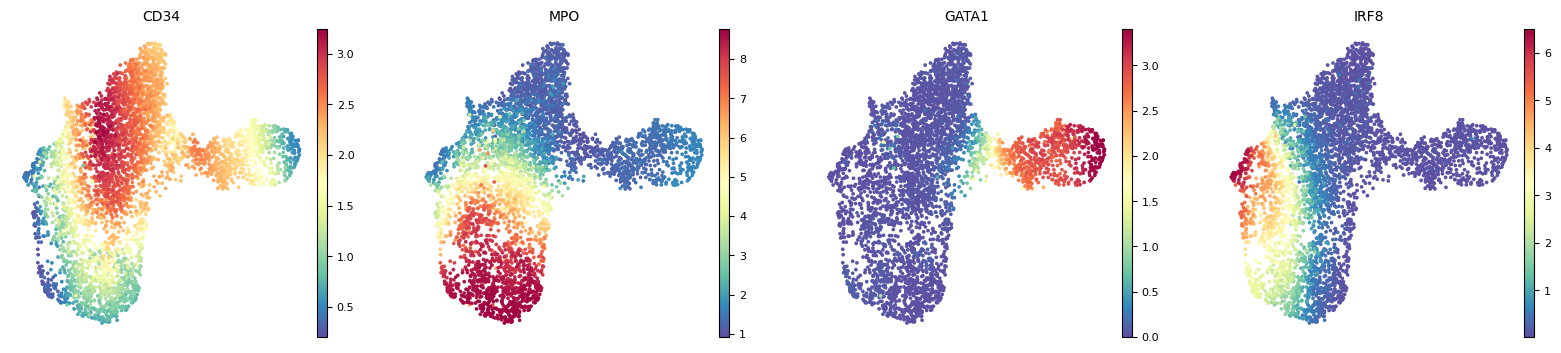

In [4]:
sc.pl.embedding(
    ad,
    basis="umap",
    layer="MAGIC_imputed_data",
    color=["CD34", "MPO", "GATA1", "IRF8"],
    frameon=False,
)
plt.show()

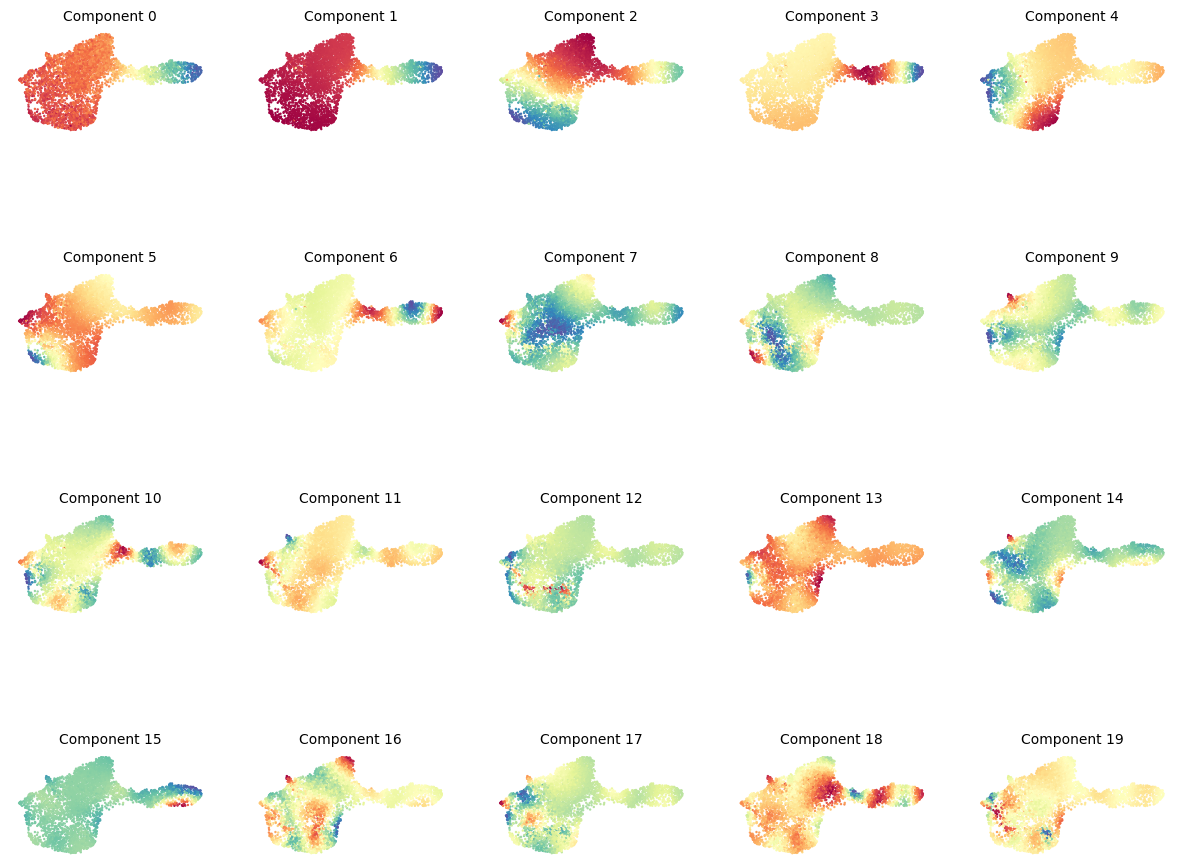

In [5]:
palantir.plot.plot_diffusion_components(ad)
plt.show()

## Step 2 — Palantir pseudotime, branches & visualization

In [6]:
# ── Step 2: Palantir (identical to sample notebook) ────────────────────────
pr_res = palantir.core.run_palantir(
    ad,
    START_CELL,
    num_waypoints   = N_WAYPOINTS,
    terminal_states = TERMINAL_STATES,
)
print('Palantir results:')
print(f'  Pseudotime range: [{ad.obs["palantir_pseudotime"].min():.3f}, '
      f'{ad.obs["palantir_pseudotime"].max():.3f}]')
print(f'  Fate prob columns: {list(ad.obsm["palantir_fate_probabilities"].columns)}')

Sampling and flocking waypoints...
Time for determining waypoints: 6.651878356933594e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...


Time for shortest paths: 0.00919566551844279 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9991
Correlation at iteration 2: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


Palantir results:
  Pseudotime range: [0.000, 1.000]
  Fate prob columns: ['Ery', 'DC', 'Mono']


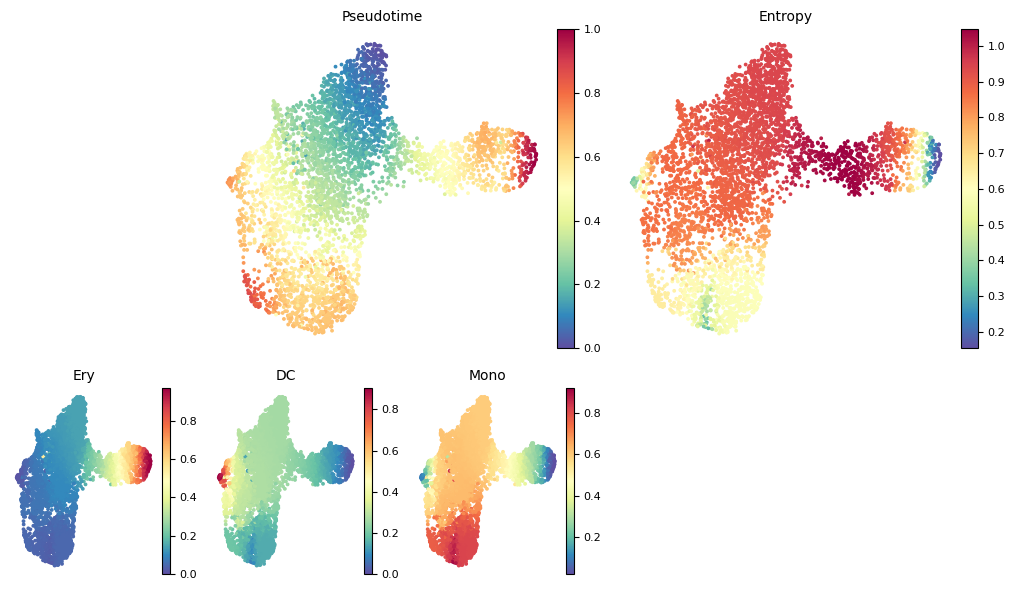

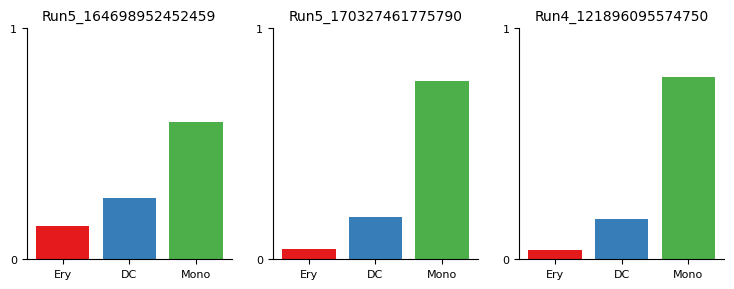

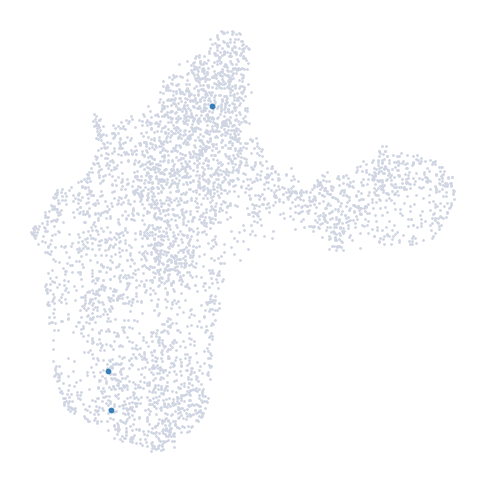

In [7]:
palantir.plot.plot_palantir_results(ad, s=3)
plt.show()
cells = [
    "Run5_164698952452459",
    "Run5_170327461775790",
    "Run4_121896095574750",
]
palantir.plot.plot_terminal_state_probs(ad, cells)
plt.show()
palantir.plot.highlight_cells_on_umap(ad, cells)
plt.show()


Branch cell counts:
  Ery: 1151 cells (28%)
  DC: 1903 cells (46%)
  Mono: 2008 cells (48%)


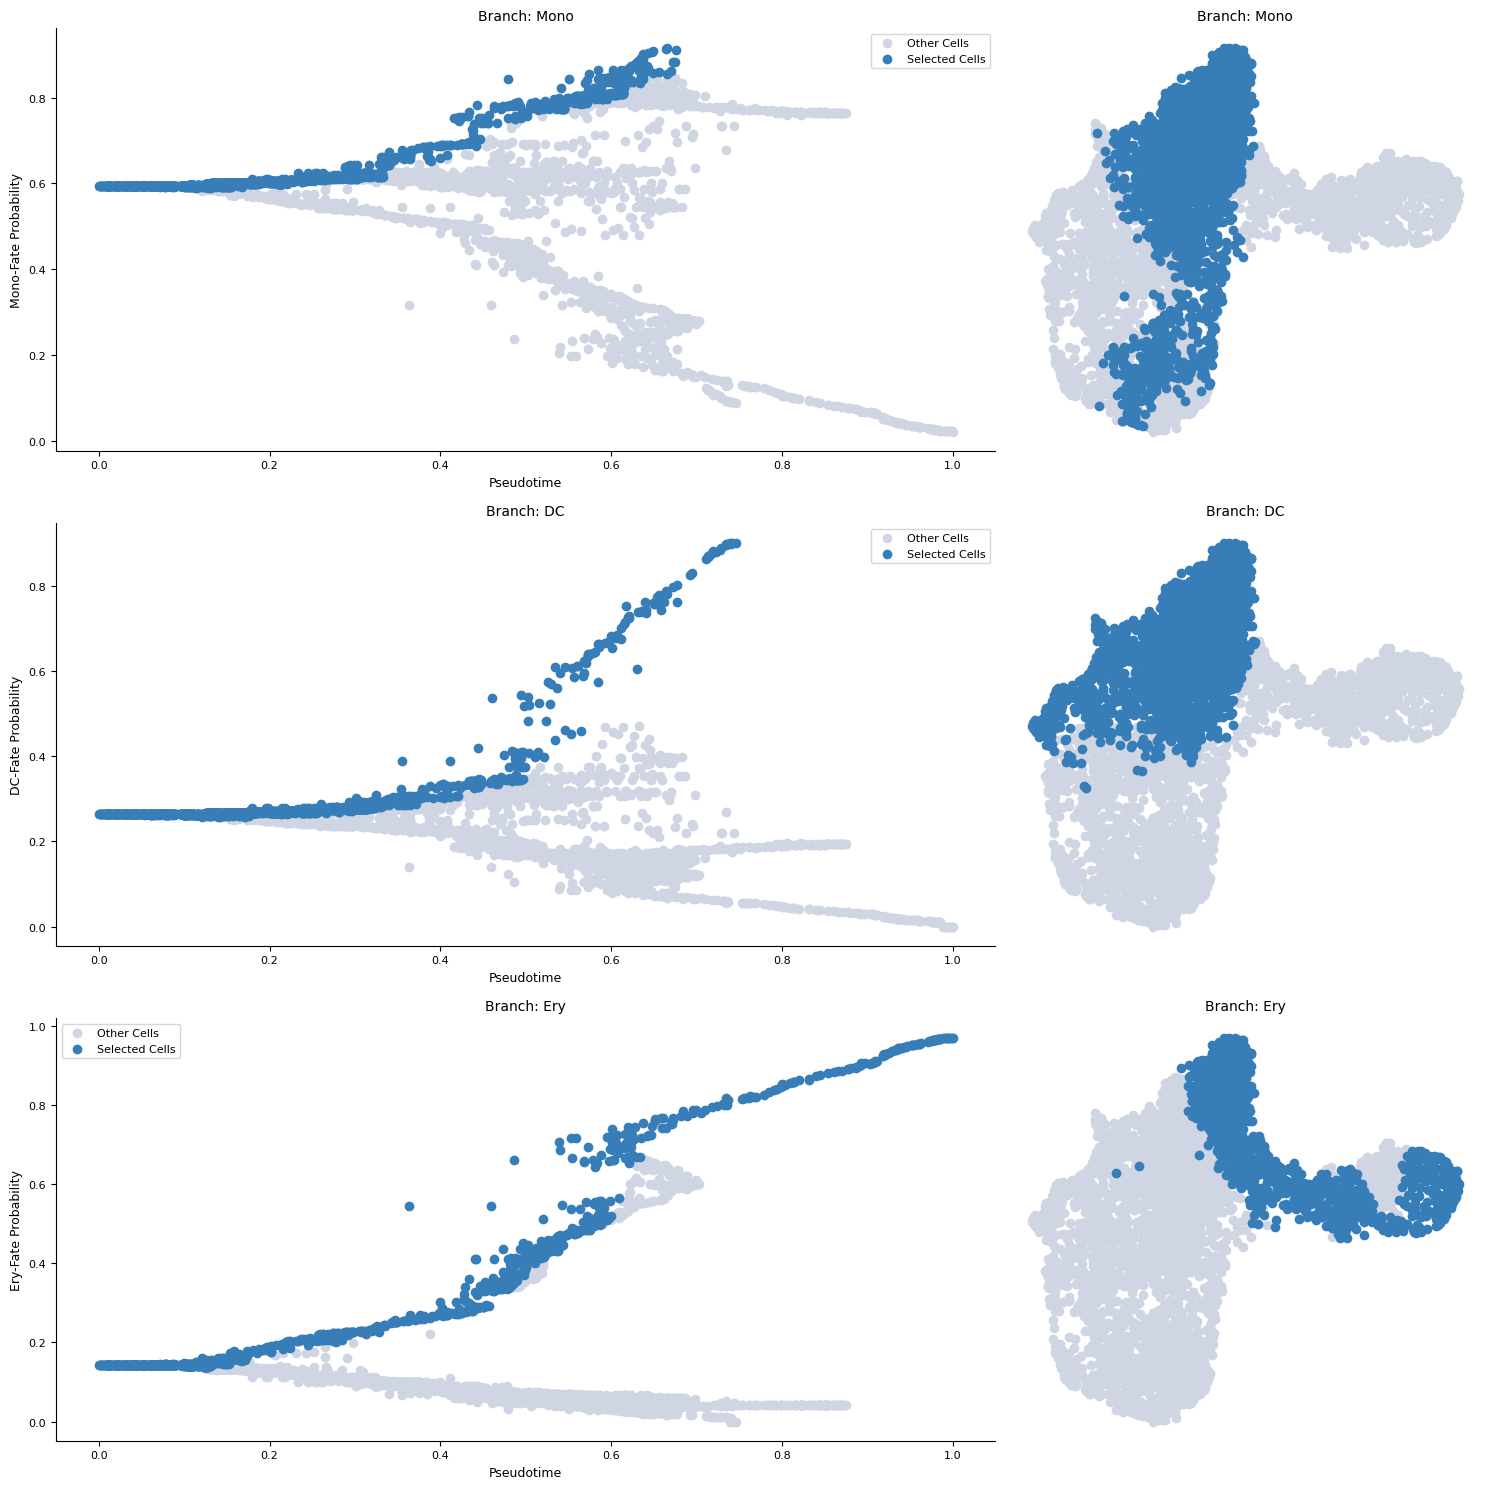

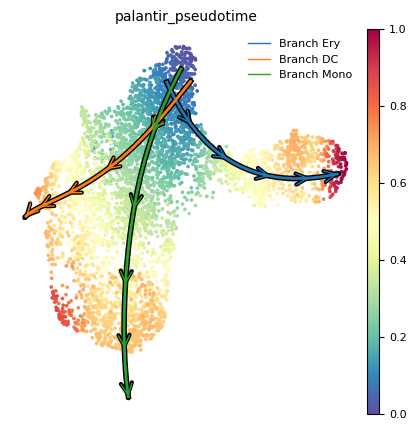

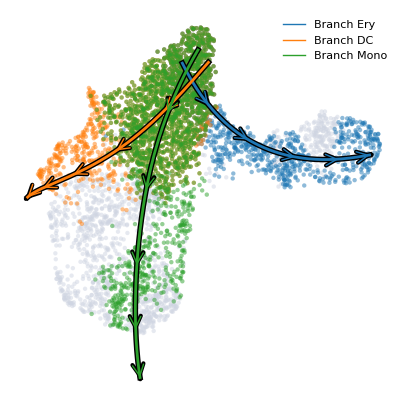

In [8]:
# Branch cell selection
palantir.presults.select_branch_cells(
    ad, q=0.01, eps=0.01,
    masks_key='branch_masks', save_as_df=True,
)
print('\nBranch cell counts:')
for col in ad.obsm['branch_masks'].columns:
    n = ad.obsm['branch_masks'][col].sum()
    print(f'  {col}: {n} cells ({100*n/ad.n_obs:.0f}%)')

# Branch-selection visualizations (from the Palantir FA tutorial)
palantir.plot.plot_branch_selection(ad)
plt.show()

palantir.plot.plot_trajectories(ad, pseudotime_interval=(0, .9))
# When using cell_color="branch_selection" be aware of the overlap between branches:
palantir.plot.plot_trajectories(ad, cell_color = "branch_selection", pseudotime_interval=(0, .9))
plt.show()

In [9]:
# Cell fate labels for velocity bias
# High-entropy cells → 'Progenitor'; all others → dominant fate label
fate_probs = ad.obsm['palantir_fate_probabilities']
ad.obs['cell_fate'] = fate_probs.idxmax(axis=1).astype(str)
entropy_thr = ad.obs['palantir_entropy'].quantile(0.75)
ad.obs.loc[ad.obs['palantir_entropy'] >= entropy_thr, 'cell_fate'] = 'Progenitor'

print('\nCell fate labels (velocity bias prior):')
print(ad.obs['cell_fate'].value_counts().to_string())


Cell fate labels (velocity bias prior):
cell_fate
Mono          2718
Progenitor    1036
Ery            298
DC              90


## Step 3 — Branch-separated scJDO drift fields, figure & summary

[bias] Progenitor 'Progenitor': 1036 cells, centroid computed in X_fa

Branch: Ery  (1151 cells)
  [bias] Terminal 'Ery': 298 cells | bias_strength=1.5
  [bias] Alignment with prog→terminal axis: 0.221
Computing pseudotime-gradient velocity prior...


DriftField: 879,292 parameters | device=cpu | epochs=5000


Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

Training complete. Final loss: 59.9054
Computing per-cell Jacobians...


Per-cell Jacobians:   0%|          | 0/9 [00:00<?, ?it/s]

...

  h=0.030  R=0.861  C=0.114  L=0.897  S=0.0878  n_eff_min(interior)=0.0


  h=0.050  R=0.746  C=0.088  L=0.079  S=0.0052  n_eff_min(interior)=9.4


  h=0.080  R=0.848  C=0.073  L=0.000  S=0.0000  n_eff_min(interior)=63.2


  h=0.100  R=0.903  C=0.068  L=0.000  S=0.0000  n_eff_min(interior)=125.7
[kernel-windowing] selected h*=0.0800  R=0.848  C=0.073  L=0.000  S=0.0000
Running archetype decomposition (semi-NMF)...


Done. R²=1.000 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=1.000  stored in adata.uns['scjdo_Mono']

Branch results stored: ['scjdo_Ery', 'scjdo_DC', 'scjdo_Mono']

scJDO branch results (FactorAnalysis latent space):
  Ery   : R²=0.998, n=1151, peak_t=0.724, max_eig=0.0435, n_sensitive=0/200
  DC    : R²=1.000, n=1903, peak_t=0.980, max_eig=0.0252, n_sensitive=0/200
  Mono  : R²=1.000, n=2008, peak_t=0.020, max_eig=-0.0408, n_sensitive=0/200


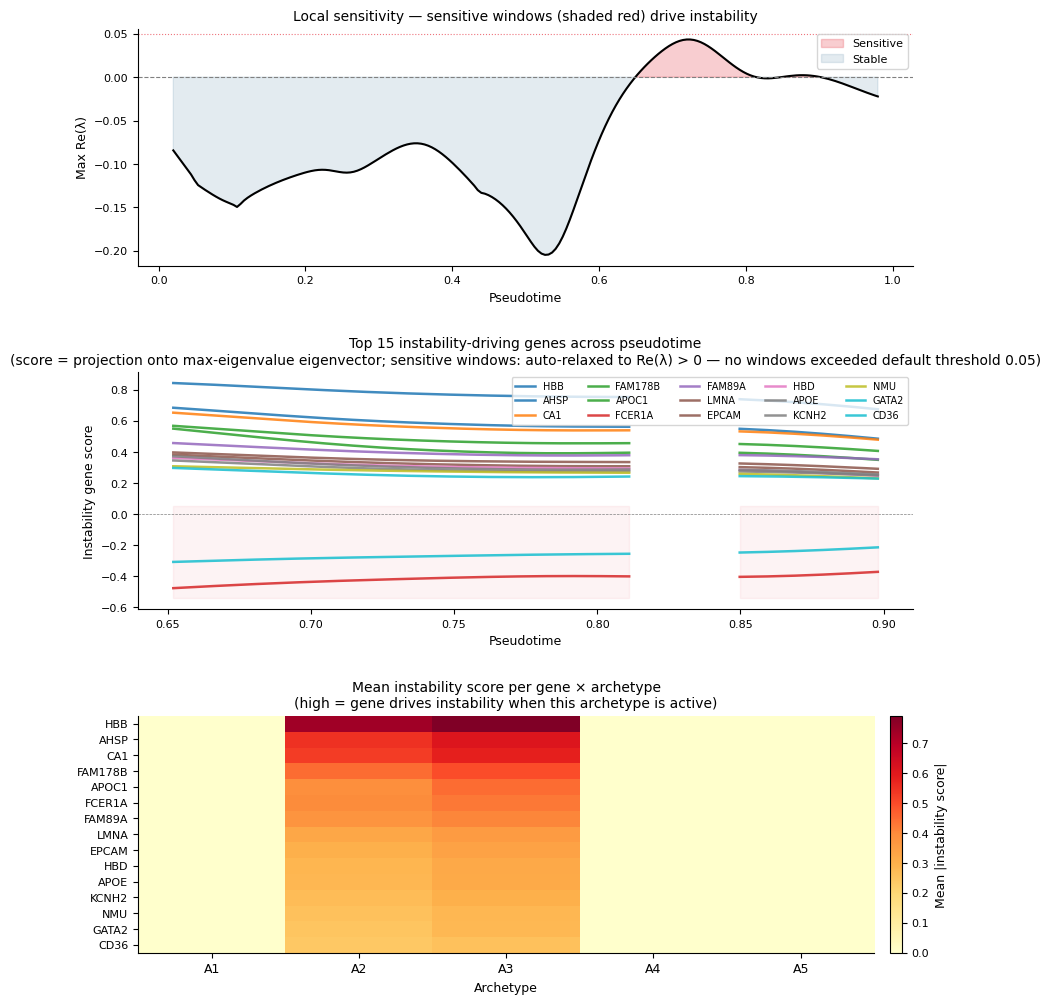

 rank    gene  mean_instability_score  peak_pseudotime primary_archetype
    1     HBB                  0.7677            0.652                A3
    2    AHSP                  0.5833            0.652                A3
    3     CA1                  0.5591            0.652                A3
    4 FAM178B                  0.4764            0.652                A3
    5   APOC1                  0.4241            0.652                A3
    6  FCER1A                  0.4161            0.652                A3
    7  FAM89A                  0.3943            0.652                A3
    8    LMNA                  0.3438            0.652                A3
    9   EPCAM                  0.3218            0.652                A3
   10     HBD                  0.3046            0.652                A3
   11    APOE                  0.3028            0.652                A3
   12   KCNH2                  0.2883            0.652                A3
   13     NMU                  0.2725            0.

[network] CollecTRI loaded — 42,990 edges, 1185 TFs



Ery:
  Top instab genes: ['HBB', 'AHSP', 'CA1', 'FAM178B', 'APOC1', 'FCER1A', 'FAM89A', 'LMNA', 'EPCAM', 'HBD']
  Top regulators:   ['GATA1', 'SP1', 'SPI1', 'TP53', 'MYB', 'POU2F1', 'NFE2', 'AP1', 'JUN', 'MYC']


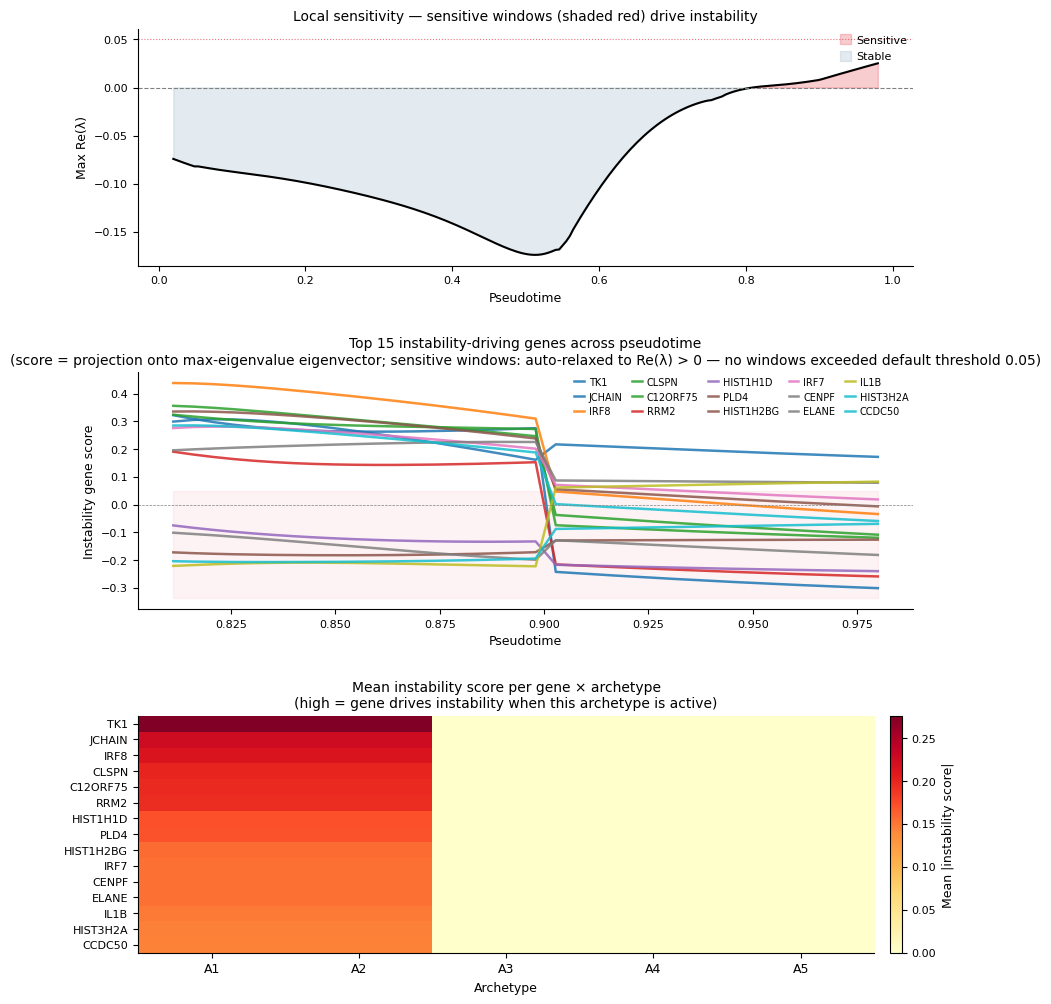

 rank      gene  mean_instability_score  peak_pseudotime primary_archetype
    1       TK1                  0.2758            0.811                A2
    2    JCHAIN                  0.2260            0.821                A2
    3      IRF8                  0.2138            0.811                A2
    4     CLSPN                  0.2000            0.811                A2
    5  C12ORF75                  0.1966            0.811                A2
    6      RRM2                  0.1944            0.980                A2
    7  HIST1H1D                  0.1708            0.980                A2
    8      PLD4                  0.1693            0.816                A2
    9 HIST1H2BG                  0.1552            0.850                A2
   10      IRF7                  0.1538            0.821                A2
   11     CENPF                  0.1535            0.898                A2
   12     ELANE                  0.1530            0.893                A2
   13      IL1B          


DC:
  Top instab genes: ['TK1', 'JCHAIN', 'IRF8', 'CLSPN', 'C12ORF75', 'RRM2', 'HIST1H1D', 'PLD4', 'HIST1H2BG', 'IRF7']
  Top regulators:   ['SP1', 'SPI1', 'E2F1', 'CREB1', 'E2F4', 'YY1', 'CEBPB', 'RELA', 'NFKB1', 'EGR1']


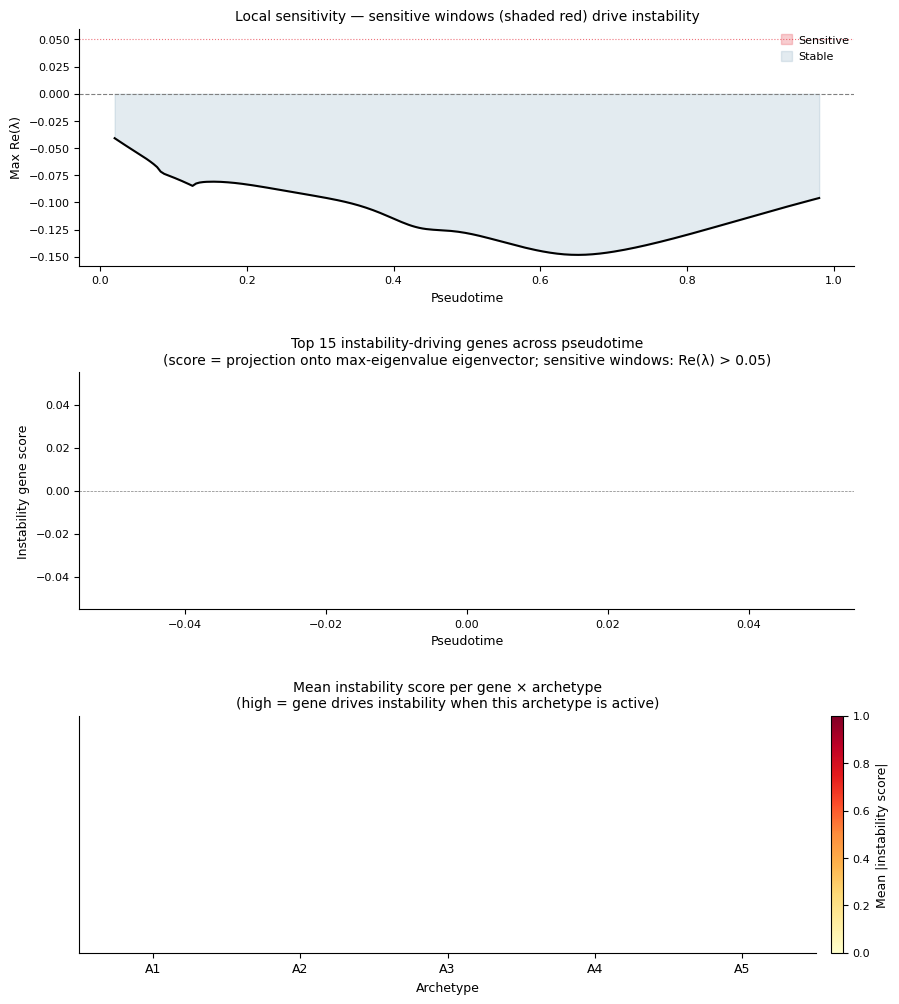

Empty DataFrame
Columns: []
Index: []
  [Mono] infer_regulators: No regulator results. Check that instability scores are computed. — empty fallback

Mono:
  Top instab genes: []
  Top regulators:   ['(none)']


In [10]:
# ── Step 3: Branch-separated scJDO drift fields (FactorAnalysis latent space) ───────
# branch_names = ['DC', 'Mono', 'Ery'] from Palantir terminal_states labels.
# terminal_clusters keys must match branch names exactly.
# varm["PCs"] shape = (n_genes, N_LATENT) — FactorAnalysis loadings (genes x factors). ✓
branch_models = sjd.tl.fit_drift_branches(
    ad,
    rep                = 'X_fa',          # drift field fit in FactorAnalysis space
    branch_key         = 'branch_masks',
    branch_names       = list(ad.obsm['branch_masks'].columns),
    time_key           = 'palantir_pseudotime',
    groupby            = 'cell_fate',
    progenitor_cluster = 'Progenitor',
    terminal_clusters  = {'DC': 'DC', 'Mono': 'Mono', 'Ery': 'Ery'},
    bias_strength      = BIAS_STRENGTH,
    n_archetypes       = N_ARCHETYPES,
    n_epochs           = N_EPOCHS,
    vel_scale          = 2.0,
    seed               = SEED,
)

print('\nscJDO branch results (FactorAnalysis latent space):')
for name in branch_models:
    key  = f'scjdo_{name}'
    res  = ad.uns[key]
    eig  = res['max_real_eig']
    peak = res['t_centers'][np.argmax(eig)]
    n_sens = (eig > 0.05).sum()
    print(f"  {name:6s}: R²={res['r2']:.3f}, n={res['n_cells']}, "
          f"peak_t={peak:.3f}, max_eig={eig.max():.4f}, n_sensitive={n_sens}/{len(eig)}")

# ── Step 4: Instability genes + regulators per lineage ─────────────────────
# `sjd.tl.branch_drift_analysis` wraps the per-branch loop, the subset/uns
# roundtrip (`ad_b.uns[key] = ad.uns[key]` going in, `ad.uns[reg_key] =
# ad_b.uns[reg_key]` coming back), the empty-regulator ValueError fallback,
# and per-branch artifact writes (instab_{branch}.pdf, instability_genes_
# {branch}.csv, regulators_{branch}.csv). Returns two dicts:
#   df_genes : {branch -> instability-gene table}
#   df_regs  : {branch -> regulator table (empty DataFrame if none)}
df_genes, df_regs = sjd.tl.branch_drift_analysis(
    ad, branch_models,
    key_prefix       = 'scjdo',
    n_genes          = 15,
    organism         = 'human',
    min_targets      = 1,
    n_top_regulators = 15,
    save_dir         = OUTDIR,
)


### Per-branch regulator plots — 4 panels for Ery / DC / Mono
Uses the `scjdo_regulators_{name}` tables stored by the `infer_regulators` loop above. `regulator_heatmap` and `regulator_profiles` also need the underlying drift result (`scjdo_{name}`) for archetype activations; the other two panels do not.

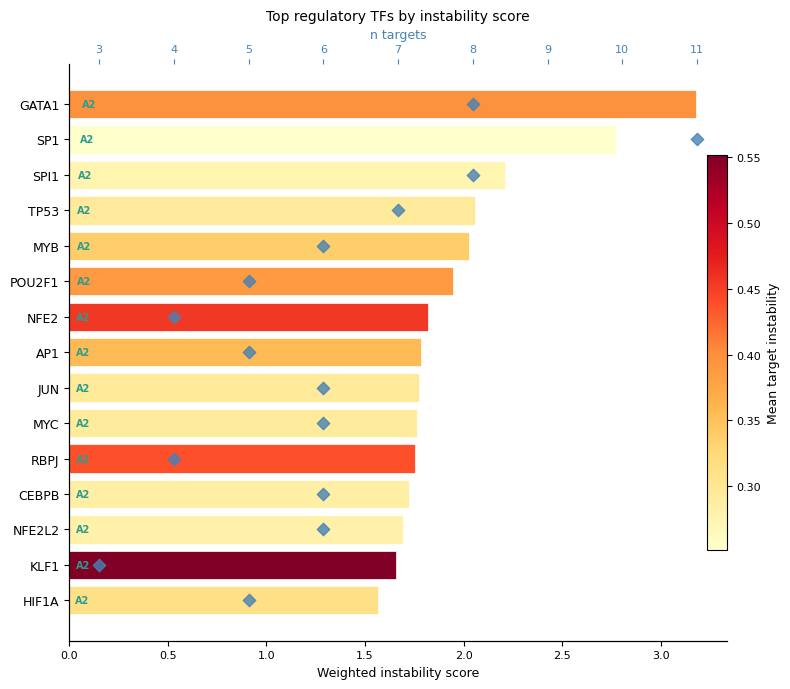

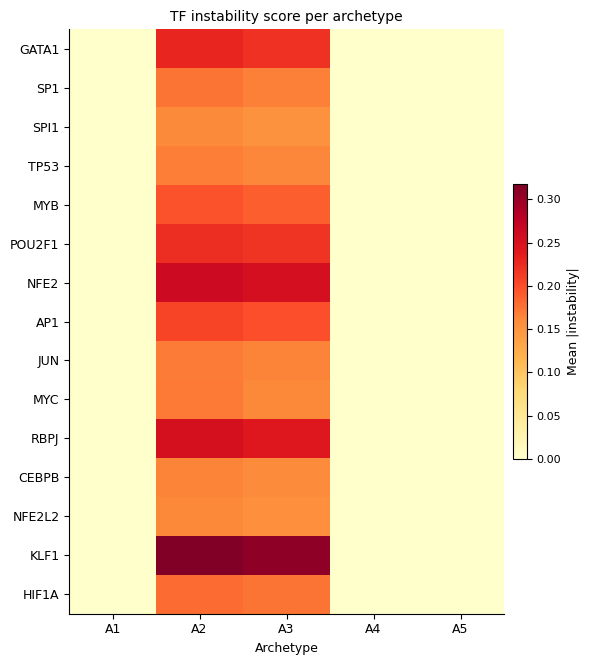

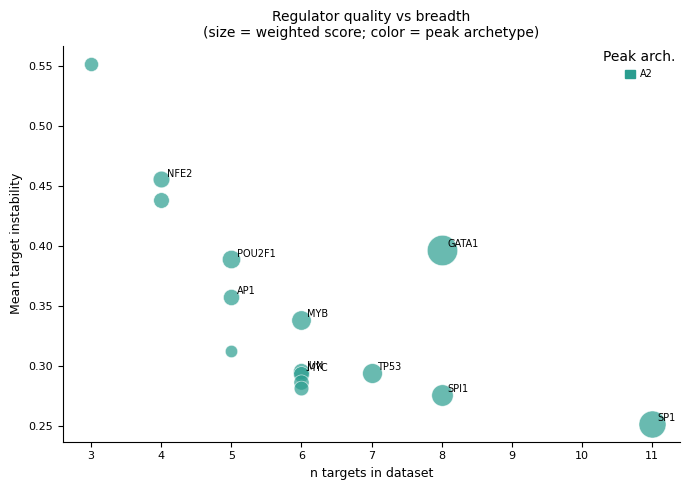

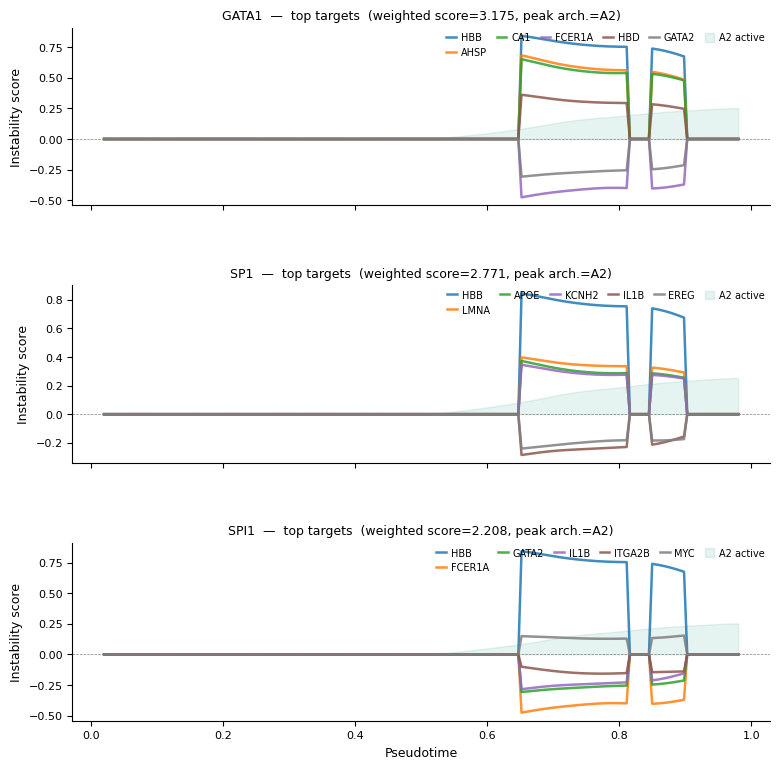

Saved: ../results/figure3/Ery/reg_summary.pdf


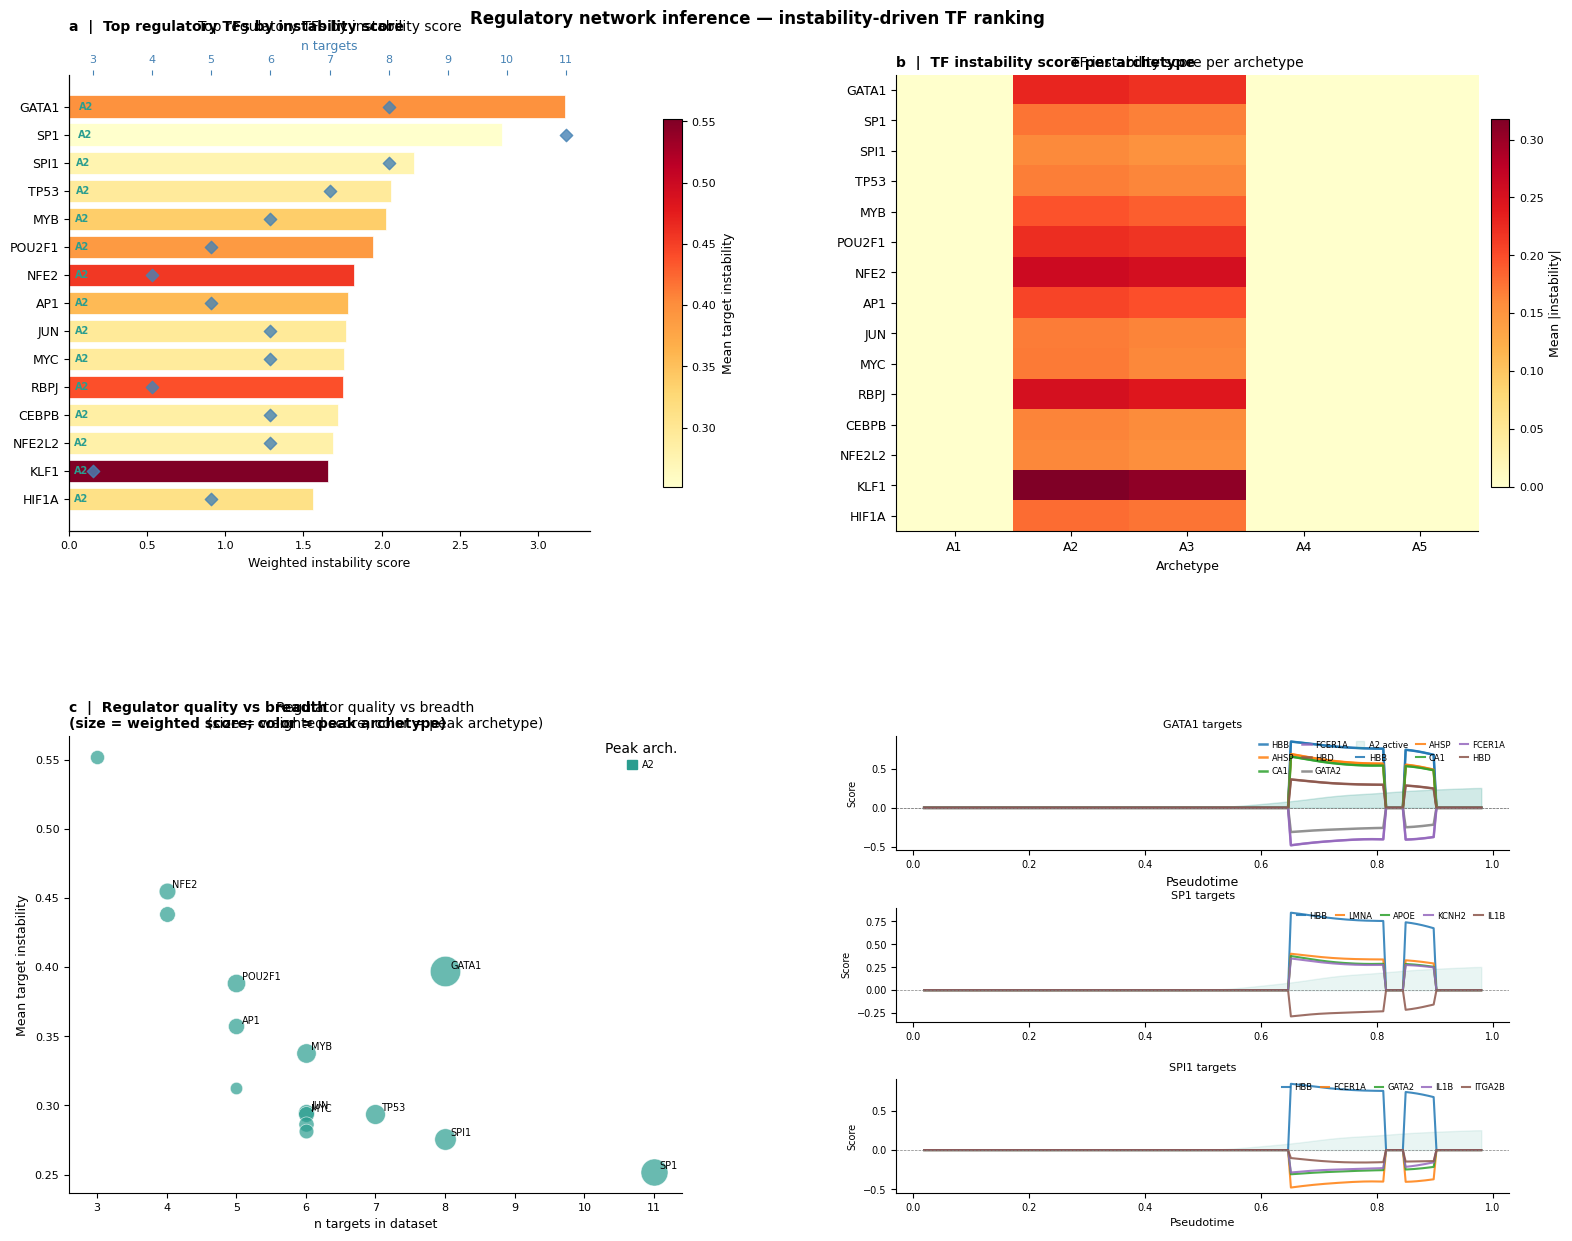

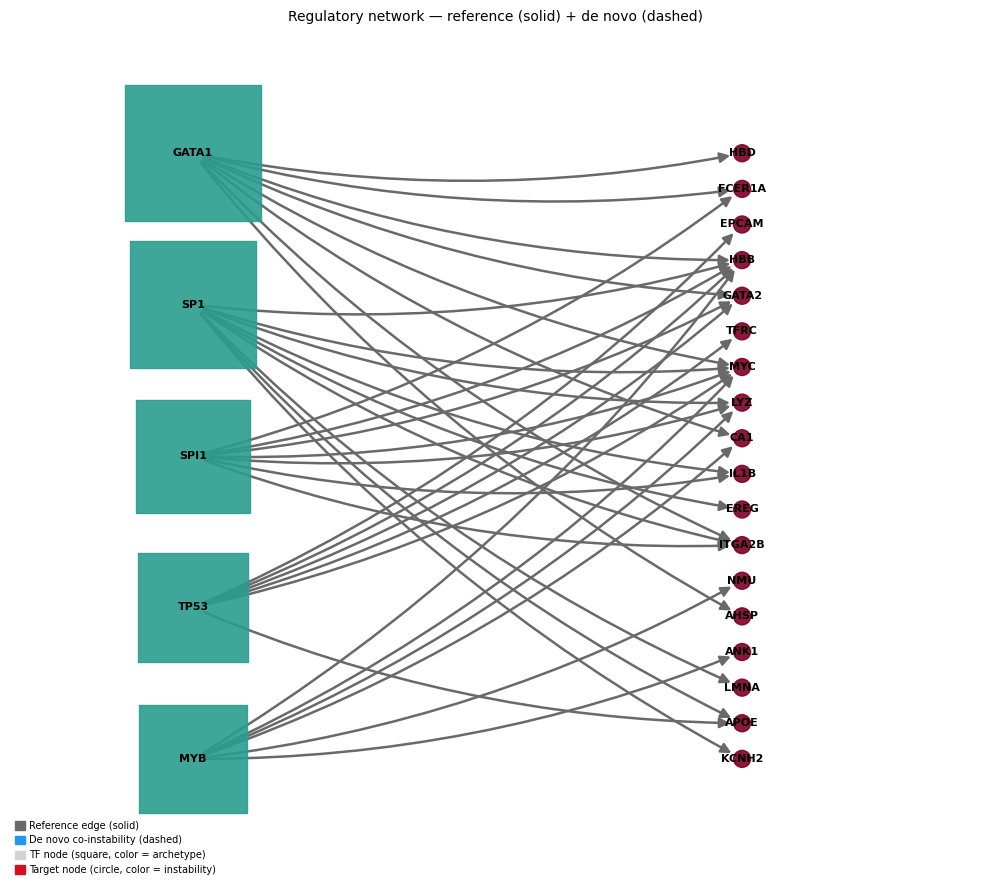

[Ery] saved 6/6 panels -> ../results/figure3/Ery  (barplot, heatmap, scatter, profiles, summary, network)


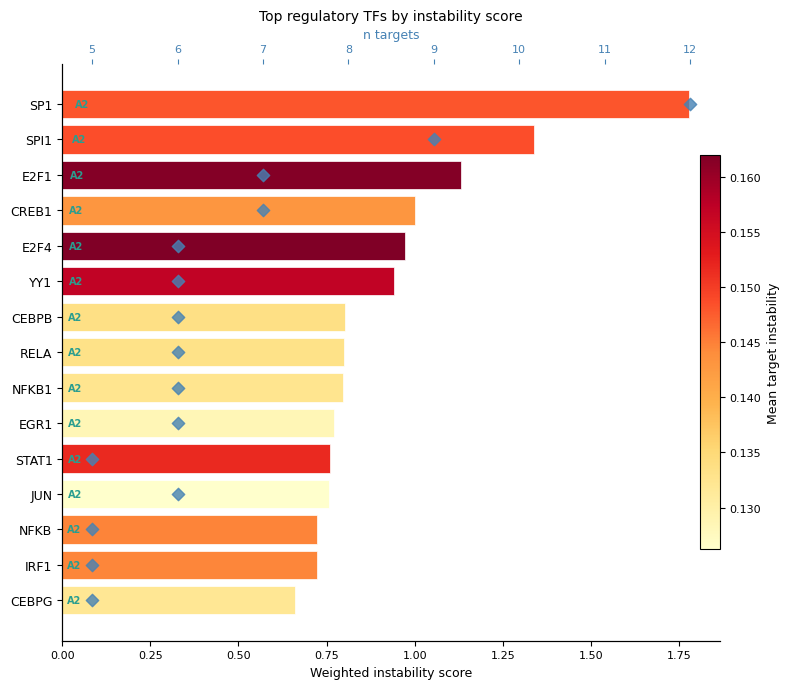

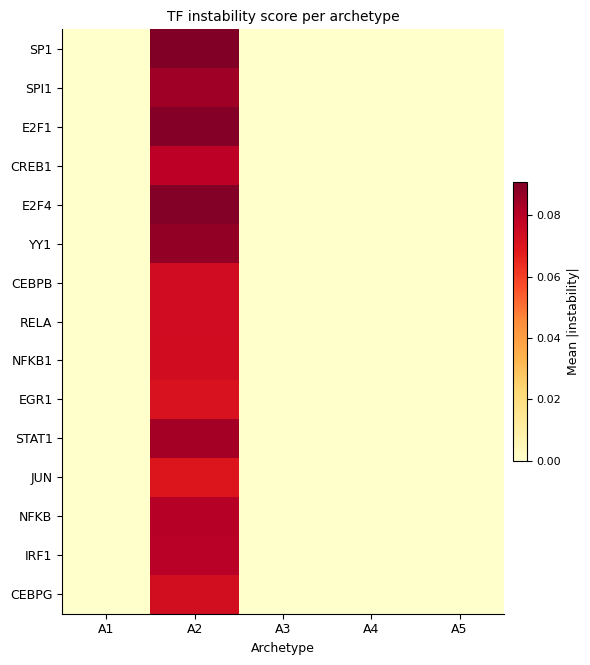

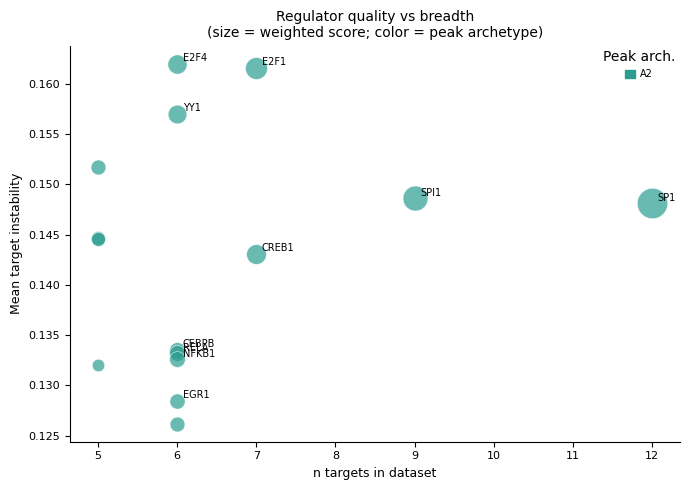

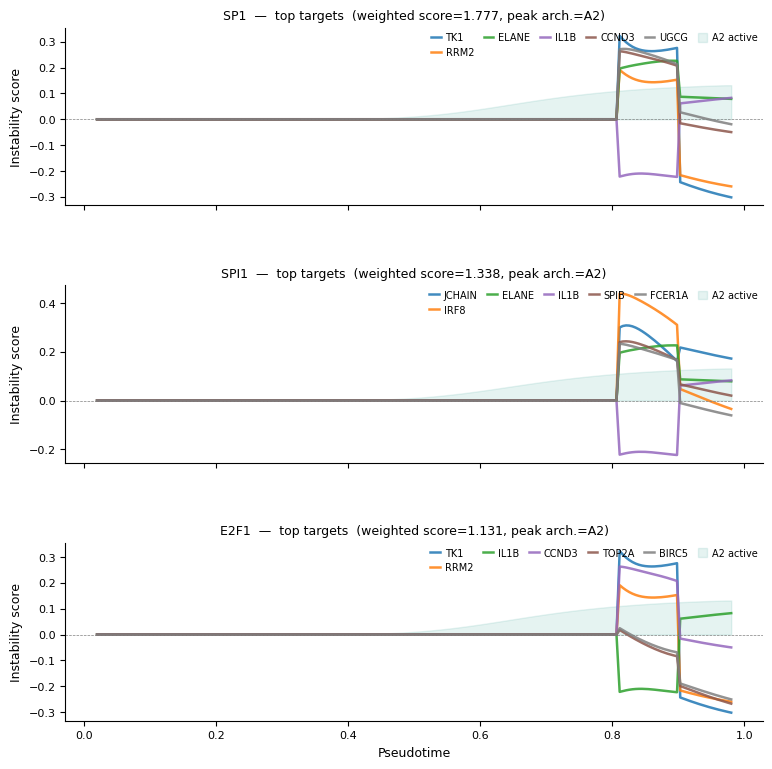

Saved: ../results/figure3/DC/reg_summary.pdf


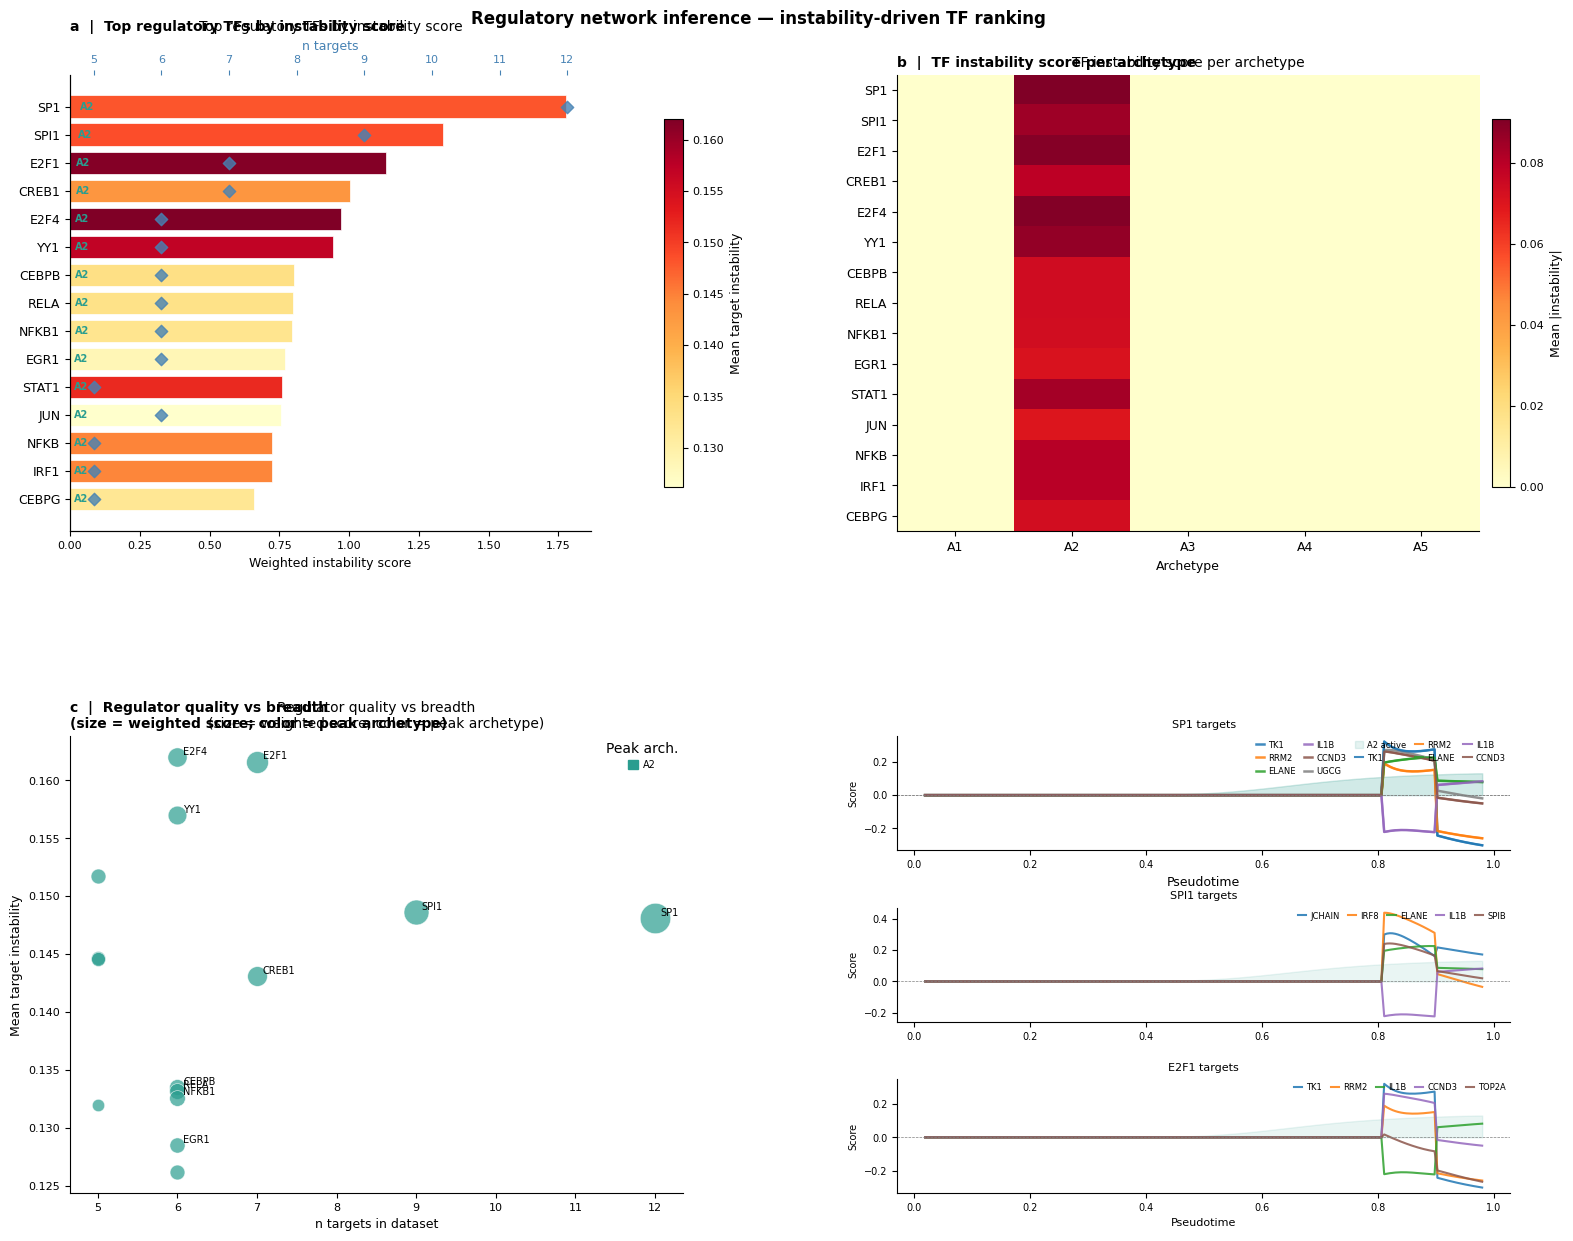

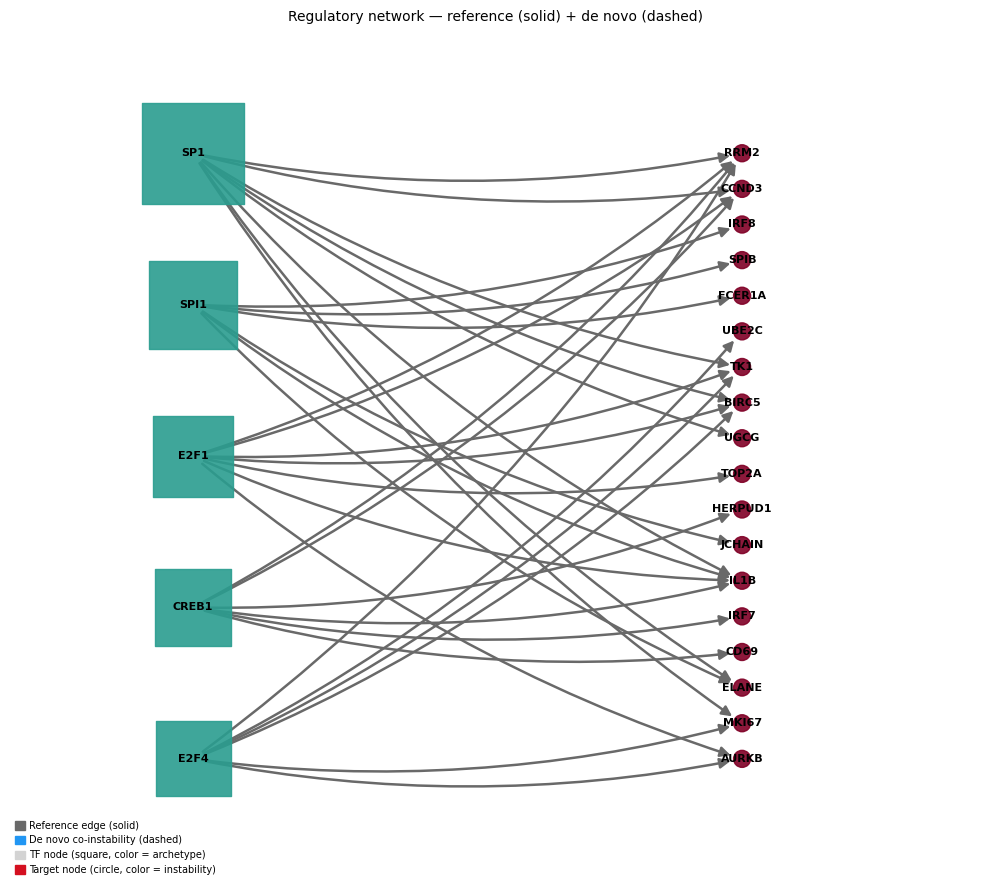

[DC] saved 6/6 panels -> ../results/figure3/DC  (barplot, heatmap, scatter, profiles, summary, network)
[Mono] no regulator table — skipping plots


{'Ery': ['barplot', 'heatmap', 'scatter', 'profiles', 'summary', 'network'],
 'DC': ['barplot', 'heatmap', 'scatter', 'profiles', 'summary', 'network'],
 'Mono': []}

In [11]:
# ── Per-branch regulator plots (Ery / DC / Mono) ──────────────────────────
# Single API call replaces the previous 30-line try/except harness. Writes
# six panels per branch (barplot, heatmap, scatter, profiles, summary, network)
# into per-branch subfolders under OUTDIR/{name}/, gracefully skipping any
# branch whose regulators_* uns entry is missing.
sjd.pl.branch_regulator_panels(
    ad, branch_models, OUTDIR,
    panels=('barplot', 'heatmap', 'scatter', 'profiles', 'summary', 'network'),
    key_prefix='scjdo', regulators_prefix='scjdo_regulators',
    panel_kwargs={
        'barplot':  {'n_show': 20},
        'heatmap':  {'n_show': 15},
        'scatter':  {'n_label': 10},
        'profiles': {'n_tfs': 3},
        'network':  {'n_tfs': 5, 'n_targets': 6, 'n_denovo': 4},
    },
)


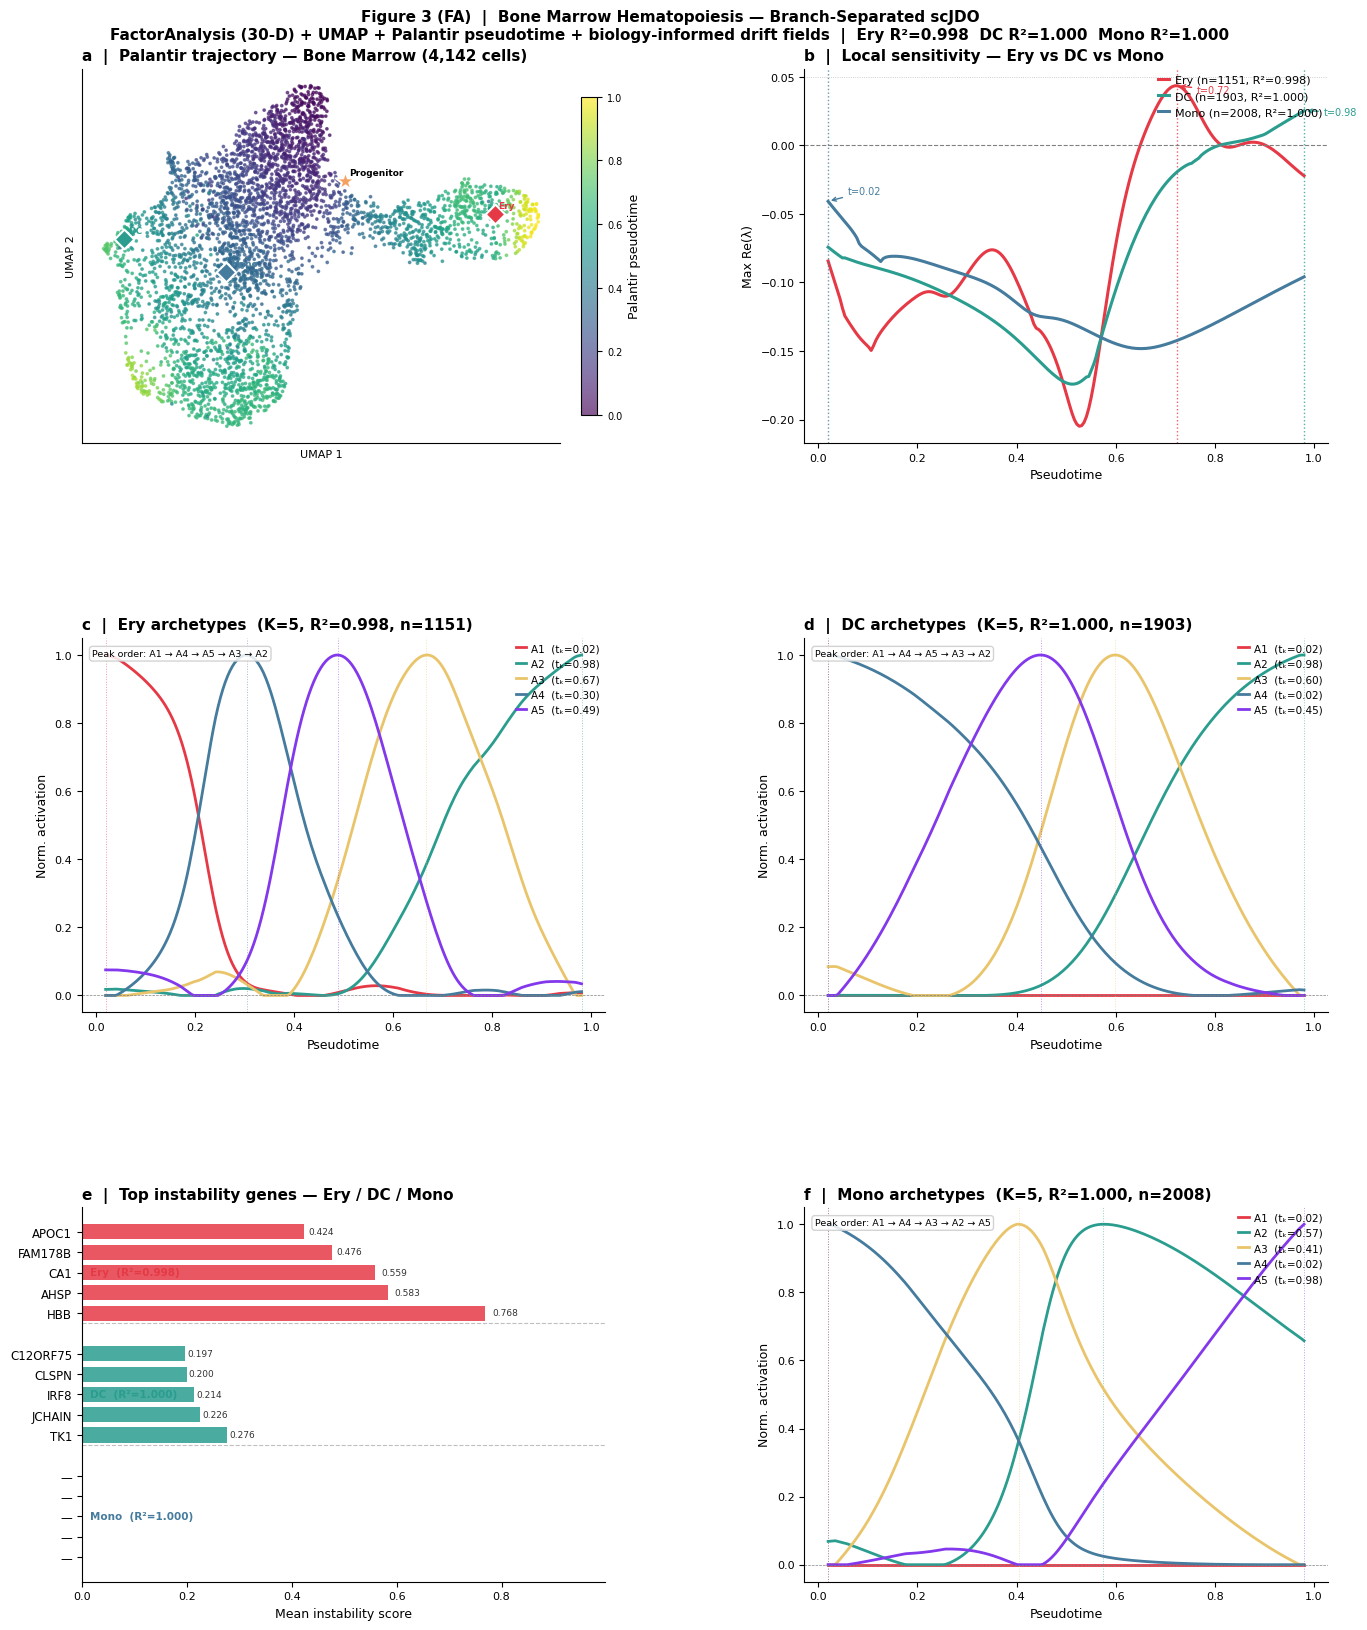

Saved: Figure3_FA.pdf / .png


In [12]:
# ── Figure layout: 3 rows × 2 cols ─────────────────────────────────────────
# (a) UMAP + pseudotime   (b) Sensitivity — all 3 lineages
# (c) Ery archetypes      (d) DC archetypes
# (e) Instability genes   (f) Mono archetypes
fig = plt.figure(figsize=(14, 17))
gs  = gridspec.GridSpec(3, 2, hspace=0.52, wspace=0.38,
                        left=0.08, right=0.97, top=0.94, bottom=0.05)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])
ax_e = fig.add_subplot(gs[2, 0])
ax_f = fig.add_subplot(gs[2, 1])

# ══════════════════════════════════════════════════════════════════════════
# Panel a: UMAP coloured by Palantir pseudotime + terminal annotations
# ══════════════════════════════════════════════════════════════════════════
umap = ad.obsm['X_umap']
pt   = ad.obs['palantir_pseudotime'].values

sc_img = ax_a.scatter(umap[:, 0], umap[:, 1], c=pt,
                      cmap='viridis', s=3, alpha=0.65, rasterized=True)
cb = plt.colorbar(sc_img, ax=ax_a, label='Palantir pseudotime',
                  fraction=0.046, pad=0.04, shrink=0.85)
cb.ax.tick_params(labelsize=7)

# Annotate progenitor and terminal populations
progenitor_mask = (ad.obs['cell_fate'] == 'Progenitor').values
if progenitor_mask.sum() > 0:
    cx = umap[progenitor_mask, 0].mean()
    cy = umap[progenitor_mask, 1].mean()
    ax_a.scatter(cx, cy, marker='*', s=220, color='#F4A261',
                 edgecolors='white', linewidths=1.5, zorder=5)
    ax_a.text(cx + 0.2, cy + 0.2, 'Progenitor',
              fontsize=6.5, fontweight='bold', color='black', zorder=6)

for branch, color in BRANCH_COLORS.items():
    mask = (ad.obs['cell_fate'] == branch).values
    if mask.sum() > 0:
        cx = umap[mask, 0].mean()
        cy = umap[mask, 1].mean()
        ax_a.scatter(cx, cy, marker='D', s=100, color=color,
                     edgecolors='white', linewidths=1.5, zorder=5)
        ax_a.text(cx + 0.2, cy + 0.2, branch,
                  fontsize=6.5, fontweight='bold', color=color, zorder=6)

ax_a.set_xlabel('UMAP 1', fontsize=8)
ax_a.set_ylabel('UMAP 2', fontsize=8)
ax_a.set_xticks([]); ax_a.set_yticks([])
ax_a.set_title('a  |  Palantir trajectory — Bone Marrow (4,142 cells)',
               fontweight='bold', loc='left', fontsize=11)

# ══════════════════════════════════════════════════════════════════════════
# Panel b: Local sensitivity — all 3 lineages
# ══════════════════════════════════════════════════════════════════════════
for name in branch_models:
    res    = ad.uns[f'scjdo_{name}']
    t      = res['t_centers']
    eig    = res['max_real_eig']
    peak_i = np.argmax(eig)
    peak_t = t[peak_i]
    peak_v = eig[peak_i]
    color  = BRANCH_COLORS.get(name, '#555')
    n      = res['n_cells']

    ax_b.plot(t, eig, color=color, lw=2.2,
              label=f'{name} (n={n}, R²={res["r2"]:.3f})')
    ax_b.fill_between(t, eig, 0, where=(eig >= 0.05),
                      alpha=0.15, color=color)
    ax_b.axvline(peak_t, color=color, lw=1.0, ls=':', alpha=0.8)
    ax_b.annotate(
        f't={peak_t:.2f}',
        xy=(peak_t, peak_v),
        xytext=(peak_t + 0.04, peak_v * 0.88),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.0),
        fontsize=7, color=color,
    )

ax_b.axhline(0,    color='gray', lw=0.8, ls='--')
ax_b.axhline(0.05, color='gray', lw=0.6, ls=':', alpha=0.5)
ax_b.set_xlabel('Pseudotime')
ax_b.set_ylabel('Max Re(λ)')
ax_b.set_title('b  |  Local sensitivity — Ery vs DC vs Mono',
               fontweight='bold', loc='left', fontsize=11)
ax_b.legend(fontsize=8, loc='upper right')

# ══════════════════════════════════════════════════════════════════════════
# Panels c, d, f: Archetype activation profiles (Ery, DC, Mono)
# ══════════════════════════════════════════════════════════════════════════
for ax, name, letter in [(ax_c, 'Ery', 'c'), (ax_d, 'DC', 'd'), (ax_f, 'Mono', 'f')]:
    key = f'scjdo_{name}'
    res = ad.uns[key]
    t   = res['t_centers']
    act = res['act_norm']
    r2  = res['r2']
    n   = res['n_cells']

    peak_ts = [t[np.argmax(act[:, k])] for k in range(K)]

    for k in range(K):
        ax.plot(t, act[:, k], color=ARCH_COLORS[k], lw=2.0,
                label=f'A{k+1}  (tₖ={peak_ts[k]:.2f})')
        ax.axvline(peak_ts[k], color=ARCH_COLORS[k], lw=0.7, ls=':', alpha=0.5)

    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel('Pseudotime')
    ax.set_ylabel('Norm. activation')
    ax.set_title(
        f'{letter}  |  {name} archetypes  (K=5, R²={r2:.3f}, n={n})',
        fontweight='bold', loc='left', fontsize=11
    )
    ax.legend(fontsize=7.5, loc='upper right', ncol=1)

    ordered   = np.argsort(peak_ts)
    order_str = ' → '.join([f'A{k+1}' for k in ordered])
    ax.text(0.02, 0.97, f'Peak order: {order_str}',
            transform=ax.transAxes, fontsize=6.8, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      alpha=0.85, edgecolor='#ccc'))

# ══════════════════════════════════════════════════════════════════════════
# Panel e: Top instability genes — all 3 lineages (horizontal barplot)
# ══════════════════════════════════════════════════════════════════════════
N_GENES = 5   # per lineage
GAP     = 1

def _get_gene_df(name, n):
    df = df_genes.get(name, pd.DataFrame())
    if len(df) == 0:
        return pd.DataFrame({'gene': ['—'] * n, 'mean_instability_score': [0.0] * n})
    df = df.head(n).reset_index(drop=True)
    while len(df) < n:
        df = pd.concat([df, pd.DataFrame({'gene': ['—'], 'mean_instability_score': [0.0]})],
                       ignore_index=True)
    return df

ery_df  = _get_gene_df('Ery',  N_GENES)
dc_df   = _get_gene_df('DC',   N_GENES)
mono_df = _get_gene_df('Mono', N_GENES)

y_mono = np.arange(N_GENES)
y_dc   = np.arange(N_GENES + GAP, N_GENES * 2 + GAP)
y_ery  = np.arange(N_GENES * 2 + GAP * 2, N_GENES * 3 + GAP * 2)

ax_e.barh(y_ery,  ery_df['mean_instability_score'],  color=BRANCH_COLORS['Ery'],  alpha=0.85, height=0.75)
ax_e.barh(y_dc,   dc_df['mean_instability_score'],   color=BRANCH_COLORS['DC'],   alpha=0.85, height=0.75)
ax_e.barh(y_mono, mono_df['mean_instability_score'], color=BRANCH_COLORS['Mono'], alpha=0.85, height=0.75)

for y_arr, df in [(y_ery, ery_df), (y_dc, dc_df), (y_mono, mono_df)]:
    for y, val in zip(y_arr, df['mean_instability_score']):
        if val > 0:
            ax_e.text(val * 1.02, y, f'{val:.3f}',
                      va='center', ha='left', fontsize=6.5, color='#333')

all_labels = (list(mono_df['gene']) + [''] * GAP +
              list(dc_df['gene'])   + [''] * GAP +
              list(ery_df['gene']))
all_y = (list(y_mono) + [N_GENES - 0.5] +
         list(y_dc)   + [N_GENES * 2 + GAP - 0.5] +
         list(y_ery))
ax_e.set_yticks(list(y_mono) + list(y_dc) + list(y_ery))
ax_e.set_yticklabels(list(mono_df['gene']) + list(dc_df['gene']) + list(ery_df['gene']),
                     fontsize=8.5)
ax_e.axhline(N_GENES + GAP / 2,         color='gray', lw=0.8, ls='--', alpha=0.5)
ax_e.axhline(N_GENES * 2 + GAP * 1.5,  color='gray', lw=0.8, ls='--', alpha=0.5)

x_max = max(
    ery_df['mean_instability_score'].max(),
    dc_df['mean_instability_score'].max(),
    mono_df['mean_instability_score'].max(), 0.01
)
for y_center, name in [(y_ery.mean(), 'Ery'), (y_dc.mean(), 'DC'), (y_mono.mean(), 'Mono')]:
    r2_val = ad.uns[f'scjdo_{name}']['r2']
    ax_e.text(x_max * 0.02, y_center, f'{name}  (R²={r2_val:.3f})',
              va='center', color=BRANCH_COLORS[name], fontsize=7.5, fontweight='bold')

ax_e.set_xlabel('Mean instability score')
ax_e.set_title('e  |  Top instability genes — Ery / DC / Mono',
               fontweight='bold', loc='left', fontsize=11)
ax_e.set_xlim(0, x_max * 1.30)

# ══════════════════════════════════════════════════════════════════════════
# Overall title + save
# ══════════════════════════════════════════════════════════════════════════
r2_str = '  '.join([f"{n} R²={ad.uns[f'scjdo_{n}']['r2']:.3f}" for n in branch_models])

fig.suptitle(
    'Figure 3 (FA)  |  Bone Marrow Hematopoiesis — Branch-Separated scJDO\n'
    f'FactorAnalysis ({N_LATENT}-D) + UMAP + Palantir pseudotime + biology-informed drift fields  |  {r2_str}',
    fontsize=11, fontweight='bold', y=0.975,
)

fig.savefig(OUTDIR + 'Figure3_FA.pdf', dpi=600, bbox_inches='tight')
fig.savefig(OUTDIR + 'Figure3_FA.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: Figure3_FA.pdf / .png')

In [13]:
# ── Summary statistics ─────────────────────────────────────────────────────
import json

rows = []
for name in branch_models:
    key  = f'scjdo_{name}'
    res  = ad.uns[key]
    eig  = res['max_real_eig']
    peak_i = np.argmax(eig)
    rows.append({
        'branch':              name,
        'n_cells':             res['n_cells'],
        'r2':                  round(float(res['r2']), 3),
        'peak_sensitivity_pt': round(float(res['t_centers'][peak_i]), 3),
        'max_sensitivity':     round(float(eig[peak_i]), 4),
        'top_instab_gene':     (res['top_instability_genes'][0]
                                if res.get('top_instability_genes') else ''),
        'top_regulator':       (df_regs[name]['regulator'].iloc[0]
                                if len(df_regs.get(name, [])) > 0 else ''),
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(OUTDIR + 'branch_summary.csv', index=False)

print('=' * 65)
print('FIGURE 3 (FA) — KEY NUMBERS  [FactorAnalysis + Palantir]')
print('=' * 65)
print(summary_df.to_string(index=False))
print()
for name in branch_models:
    genes = df_genes.get(name, pd.DataFrame())
    regs  = df_regs.get(name, pd.DataFrame())
    print(f'{name}:')
    print(f'  Top 5 genes:  {genes["gene"].head(10).tolist() if len(genes) else []}')
    print(f'  Top 5 TFs:    {regs["regulator"].head(4).tolist() if len(regs) else []}')
print()
print(f'All outputs in: {OUTDIR}')

FIGURE 3 (FA) — KEY NUMBERS  [FactorAnalysis + Palantir]
branch  n_cells    r2  peak_sensitivity_pt  max_sensitivity top_instab_gene top_regulator
   Ery     1151 0.998                0.724           0.0435             HBB         GATA1
    DC     1903 1.000                0.980           0.0252             TK1           SP1
  Mono     2008 1.000                0.020          -0.0408                              

Ery:
  Top 5 genes:  ['HBB', 'AHSP', 'CA1', 'FAM178B', 'APOC1', 'FCER1A', 'FAM89A', 'LMNA', 'EPCAM', 'HBD']
  Top 5 TFs:    ['GATA1', 'SP1', 'SPI1', 'TP53']
DC:
  Top 5 genes:  ['TK1', 'JCHAIN', 'IRF8', 'CLSPN', 'C12ORF75', 'RRM2', 'HIST1H1D', 'PLD4', 'HIST1H2BG', 'IRF7']
  Top 5 TFs:    ['SP1', 'SPI1', 'E2F1', 'CREB1']
Mono:
  Top 5 genes:  []
  Top 5 TFs:    []

All outputs in: ../results/figure3/
